# Introduction

### In this notebook we use [PointNet](https://arxiv.org/abs/1612.00593) to perform 3D Object Classification on [ModelNet40 Dataset](http://modelnet.cs.princeton.edu/#).

# Acknowledgements

### This work was inspired by and borrows code from [Balraj Ashwath's](https://www.kaggle.com/code/balraj98/) - [PointNet implementation](https://www.kaggle.com/code/balraj98/pointnet-for-3d-object-classification-ii-pytorch).
### I also used [Isaac Berrios's](https://github.com/itberrios/3D/tree/main/point_net) code to learn and compare.

# Importing Libraries

In [1]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

/Users/jianweishen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Creating dataset and dataloader

In [8]:
num_pts = 1024
class PointSampler(object):
    def __init__(self, output_size):
        assert isinstance(output_size, int)
        self.output_size = output_size
    
    def triangle_area(self, pt1, pt2, pt3):
        side_a = np.linalg.norm(pt1 - pt2)
        side_b = np.linalg.norm(pt2 - pt3)
        side_c = np.linalg.norm(pt3 - pt1)
        s = 0.5 * ( side_a + side_b + side_c)
        return max(s * (s - side_a) * (s - side_b) * (s - side_c), 0)**0.5

    def sample_point(self, pt1, pt2, pt3):
        # barycentric coordinates on a triangle
        # https://mathworld.wolfram.com/BarycentricCoordinates.html
        s, t = sorted([random.random(), random.random()])
        f = lambda i: s * pt1[i] + (t-s)*pt2[i] + (1-t)*pt3[i]
        return (f(0), f(1), f(2))
        
    
    def __call__(self, mesh):
        verts, faces = mesh
        verts = np.array(verts)
        areas = np.zeros((len(faces)))

        for i in range(len(areas)):
            areas[i] = (self.triangle_area(verts[faces[i][0]],
                                           verts[faces[i][1]],
                                           verts[faces[i][2]]))
            
        sampled_faces = (random.choices(faces, 
                                      weights=areas,
                                      cum_weights=None,
                                      k=self.output_size))
        
        sampled_points = np.zeros((self.output_size, 3))

        for i in range(len(sampled_faces)):
            sampled_points[i] = (self.sample_point(verts[sampled_faces[i][0]],
                                                   verts[sampled_faces[i][1]],
                                                   verts[sampled_faces[i][2]]))
        
        return sampled_points
        

class ToTensor(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        return torch.from_numpy(pointcloud)


def default_transforms():
    return transforms.Compose([
                                PointSampler(num_pts),
                                Normalize(),
                                ToTensor()
                              ])


class Normalize(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2
        
        norm_pointcloud = pointcloud - np.mean(pointcloud, axis=0) 
        norm_pointcloud /= np.max(np.linalg.norm(norm_pointcloud, axis=1))

        return  norm_pointcloud

In [4]:
def read_off(file_path):
    """ Reads an OFF file and extracts the vertex data as a NumPy array. """
    with open(file_path, 'r') as file:
        off_header = file.readline().strip()
        if 'OFF' == off_header:
            n_verts, n_faces, __ = tuple([int(s) for s in file.readline().strip().split(' ')])
        else:
            n_verts, n_faces, __ = tuple([int(s) for s in off_header[3:].split(' ')])
        verts = [[float(s) for s in file.readline().strip().split(' ')] for i_vert in range(n_verts)]
        faces = [[int(s) for s in file.readline().strip().split(' ')][1:] for i_face in range(n_faces)]
        return verts, faces

class PointCloudDataset(Dataset):
    def __init__(self, root_dir, valid=False, get_testset=False, transform=default_transforms()):
        self.root_dir = root_dir
        folders = [dr for dr in sorted(os.listdir(root_dir)) if os.path.isdir(f'{root_dir}/{dr}')]
        self.classes = {folder: i for i, folder in enumerate(folders)}
        global all_class_names
        all_class_names = list(self.classes.keys())
        self.transforms = transform if not valid else default_transforms()
        self.valid = valid
        self.files = []
        self.labels = []
        sub_folder = 'test' if get_testset else 'train'
        
        for class_name, label in self.classes.items():
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                class_dir += f'/{sub_folder}/'
                for file_name in os.listdir(class_dir):
                    if file_name.endswith('.off'):
                        self.files.append(os.path.join(class_dir, file_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __preproc__(self, file_path):
        verts, faces = read_off(file_path)
        if self.transforms:
            pointcloud = self.transforms((verts, faces))
        return pointcloud

    def __getitem__(self, idx):
        pcd_path = self.files[idx]
        label = self.labels[idx]
        pointcloud = self.__preproc__(pcd_path)
        return {'pointcloud': pointcloud, 
                'category': label}

# Load the dataset
data_path = 'ModelNet40'

train_dataset = PointCloudDataset(data_path)
val_dataset = PointCloudDataset(data_path, valid=True, get_testset=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(dataset=val_dataset, batch_size=64, num_workers=0, pin_memory=True)

# Model Definition

In [36]:
class Tnet(nn.Module):
    def __init__(self, k=3):
        super().__init__()
        self.k=k
        self.conv1 = nn.Conv1d(k,64,1)
        self.conv2 = nn.Conv1d(64,128,1)
        self.conv3 = nn.Conv1d(128,1024,1)
        self.fc1 = nn.Linear(1024,512)
        self.fc2 = nn.Linear(512,256)
        self.fc3 = nn.Linear(256,k*k)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, input):
        # input.shape == (bs,n,3)
        bs = input.size(0)
        xb = F.relu(self.bn1(self.conv1(input)))
        xb = F.relu(self.bn2(self.conv2(xb)))
        xb = F.relu(self.bn3(self.conv3(xb)))
        pool = nn.MaxPool1d(xb.size(-1))(xb)
        flat = nn.Flatten(1)(pool)
        xb = F.relu(self.bn4(self.fc1(flat)))
        xb = F.relu(self.bn5(self.fc2(xb)))

        #initialize as identity
        init = torch.eye(self.k, requires_grad=True).repeat(bs,1,1).to(device)

        matrix = self.fc3(xb).view(-1,self.k,self.k) + init
        return matrix


class Transform(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_transform = Tnet(k=3)
        self.feature_transform = Tnet(k=64)
        self.conv1 = nn.Conv1d(3,64,1)

        self.conv2 = nn.Conv1d(64,128,1)
        self.conv3 = nn.Conv1d(128,1024,1)


        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

    def forward(self, input):
        matrix3x3 = self.input_transform(input)
        # batch matrix multiplication
        xb = torch.bmm(torch.transpose(input,1,2), matrix3x3).transpose(1,2)

        xb = F.relu(self.bn1(self.conv1(xb)))

        matrix64x64 = self.feature_transform(xb)
        xb = torch.bmm(torch.transpose(xb,1,2), matrix64x64).transpose(1,2)

        xb = F.relu(self.bn2(self.conv2(xb)))
        xb = self.bn3(self.conv3(xb))
        xb = nn.MaxPool1d(xb.size(-1))(xb)
        output = nn.Flatten(1)(xb)
        return output, matrix3x3, matrix64x64

class PointNet(nn.Module):
    def __init__(self, classes = 40):
        super().__init__()
        self.transform = Transform()
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, classes)
        

        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        xb, matrix3x3, matrix64x64 = self.transform(input)
        xb = F.relu(self.bn1(self.fc1(xb)))
        xb = F.relu(self.bn2(self.dropout(self.fc2(xb))))
        output = self.fc3(xb)
        return self.logsoftmax(output), matrix3x3, matrix64x64

def pointnetloss(outputs, labels, m3x3, m64x64, alpha = 0.0001):
    criterion = torch.nn.NLLLoss()
    bs=outputs.size(0)
    id3x3 = torch.eye(3, requires_grad=True).repeat(bs,1,1)
    id64x64 = torch.eye(64, requires_grad=True).repeat(bs,1,1)
    if outputs.is_cuda:
        id3x3=id3x3.cuda()
        id64x64=id64x64.cuda()
    diff3x3 = id3x3-torch.bmm(m3x3,m3x3.transpose(1,2))
    diff64x64 = id64x64-torch.bmm(m64x64,m64x64.transpose(1,2))
    return criterion(outputs, labels) + alpha * (torch.norm(diff3x3)+torch.norm(diff64x64)) / float(bs)



import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V)
        self.fc_k = nn.Linear(dim_K, dim_V)
        self.fc_v = nn.Linear(dim_K, dim_V)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V)

    def forward(self, Q, K):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)

        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)

        A = torch.softmax(Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V), 2)
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln)

    def forward(self, X):
        return self.mab(X, X)

class ISAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, num_inds, ln=False):
        super(ISAB, self).__init__()
        self.I = nn.Parameter(torch.Tensor(1, num_inds, dim_out))
        nn.init.xavier_uniform_(self.I)
        self.mab0 = MAB(dim_out, dim_in, dim_out, num_heads, ln=ln)
        self.mab1 = MAB(dim_in, dim_out, dim_out, num_heads, ln=ln)

    def forward(self, X):
        H = self.mab0(self.I.repeat(X.size(0), 1, 1), X)
        return self.mab1(X, H)

class PMA(nn.Module):
    def __init__(self, dim, num_heads, num_seeds, ln=False):
        super(PMA, self).__init__()
        self.S = nn.Parameter(torch.Tensor(1, num_seeds, dim))
        nn.init.xavier_uniform_(self.S)
        self.mab = MAB(dim, dim, dim, num_heads, ln=ln)

    def forward(self, X):
        return self.mab(self.S.repeat(X.size(0), 1, 1), X)


class SetTransformer(nn.Module):
    def __init__(
        self,
        dim_input=3,
        num_outputs=1,
        dim_output=40,
        num_inds=32,
        dim_hidden=128,
        num_heads=4,
        ln=False,
    ):
        super(SetTransformer, self).__init__()
        self.enc = nn.Sequential(
            ISAB(dim_input, dim_hidden, num_heads, num_inds, ln=ln),
            ISAB(dim_hidden, dim_hidden, num_heads, num_inds, ln=ln),
        )
        self.dec = nn.Sequential(
            nn.Dropout(),
            PMA(dim_hidden, num_heads, num_outputs, ln=ln),
            nn.Dropout(),
            nn.Linear(dim_hidden, dim_output),
        )

    def forward(self, X):
        return self.dec(self.enc(X)).squeeze()


class DeepSet(nn.Module):
    def __init__(self, dim_input, dim_output, dim_hidden=128):
        super(DeepSet, self).__init__()
        self.dim_output = dim_output
        self.enc = nn.Sequential(
                nn.Linear(dim_input, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_hidden))
        self.dec = nn.Sequential(
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Linear(dim_hidden, dim_output))

    def forward(self, X):
        X = self.enc(X).mean(-2)
        X = self.dec(X)
        return X


class PermEqui1_max(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui1_max, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)

  def forward(self, x):
    xm, _ = x.max(1, keepdim=True)
    x = self.Gamma(x-xm)
    return x

class PermEqui1_mean(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui1_mean, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)

  def forward(self, x):
    xm = x.mean(1, keepdim=True)
    x = self.Gamma(x-xm)
    return x

class PermEqui2_max(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui2_max, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)
    self.Lambda = nn.Linear(in_dim, out_dim, bias=False)

  def forward(self, x):
    xm, _ = x.max(1, keepdim=True)
    xm = self.Lambda(xm)
    x = self.Gamma(x)
    x = x - xm
    return x

class PermEqui2_mean(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(PermEqui2_mean, self).__init__()
    self.Gamma = nn.Linear(in_dim, out_dim)
    self.Lambda = nn.Linear(in_dim, out_dim, bias=False)

  def forward(self, x):
    xm = x.mean(1, keepdim=True)
    xm = self.Lambda(xm)
    x = self.Gamma(x)
    x = x - xm
    return x


class DTanh(nn.Module):

    def __init__(self, x_dim, d_dim, output_dim, pool='mean'):
        super(DTanh, self).__init__()
        self.d_dim = d_dim
        self.x_dim = x_dim
        self.output_dim = output_dim
        self.pool = pool
        if pool == 'max':
            self.phi = nn.Sequential(
                PermEqui2_max(self.x_dim, self.d_dim),
                nn.ELU(),
                PermEqui2_max(self.d_dim, self.d_dim),
                nn.ELU(),
                PermEqui2_max(self.d_dim, self.d_dim),
                nn.ELU(),
            )
        elif pool == 'max1':
            self.phi = nn.Sequential(
                PermEqui1_max(self.x_dim, self.d_dim),
                nn.ELU(),
                PermEqui1_max(self.d_dim, self.d_dim),
                nn.ELU(),
                PermEqui1_max(self.d_dim, self.d_dim),
                nn.ELU(),
            )
        elif pool == 'mean':
            self.phi = nn.Sequential(
                PermEqui2_mean(self.x_dim, self.d_dim),
                nn.ELU(),
                PermEqui2_mean(self.d_dim, self.d_dim),
                nn.ELU(),
                PermEqui2_mean(self.d_dim, self.d_dim),
                nn.ELU(),
            )
        elif pool == 'mean1':
            self.phi = nn.Sequential(
                PermEqui1_mean(self.x_dim, self.d_dim),
                nn.ELU(),
                PermEqui1_mean(self.d_dim, self.d_dim),
                nn.ELU(),
                PermEqui1_mean(self.d_dim, self.d_dim),
                nn.ELU(),
            )

        self.projection = nn.Sequential(
            # nn.Linear(self.d_dim, self.d_dim),
            # nn.ELU(),
            nn.Linear(self.d_dim, self.d_dim),
            # nn.LayerNorm(self.d_dim),
            nn.ReLU(),
            nn.Linear(self.d_dim, self.d_dim),
            # nn.LayerNorm(self.d_dim),
            nn.ReLU(),
            nn.Linear(self.d_dim, self.d_dim),
            # nn.LayerNorm(self.d_dim),
            nn.ReLU(),
            # nn.Linear(self.d_dim, self.output_dim*self.num_outputs),
        )

        self.last_layer = nn.Sequential(
            nn.Linear(self.d_dim, self.d_dim),
            nn.ReLU(),
            nn.Linear(self.d_dim, self.output_dim)
        )

    def forward(self, x):
        phi_output = self.phi(x)
        projected_elements = self.projection(phi_output)
        if self.pool in ["max", "max1"]:
            pooled_output, _ = projected_elements.max(1)
        else:
            pooled_output = projected_elements.mean(1)
        pooled_output = self.last_layer(pooled_output)
        return pooled_output


def clip_grad(model, max_norm):
    total_norm = 0
    for p in model.parameters():
        param_norm = p.grad.data.norm(2)
        total_norm += param_norm ** 2
    total_norm = total_norm ** (0.5)
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in model.parameters():
            p.grad.data.mul_(clip_coef)
    return total_norm

# Model Instantiation

In [37]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(device)

pointnet = PointNet()
pointnet.to(device)
print(next(pointnet.parameters()).is_cuda)  # Should output True

n_heads = 4
n_anc = 16
dim_hidden =256
output_dim = 40
D = 3
setTransformer = SetTransformer(dim_hidden=dim_hidden, num_heads=n_heads, num_inds=n_anc).to(device)
ds = DeepSet(D, output_dim,dim_hidden=num_pts+1).to(device)
pads = DTanh(D, D*2, output_dim).to(device)
optimizer = torch.optim.Adam(pointnet.parameters(), lr=0.0008)
criterion = nn.CrossEntropyLoss()


mps
False


In [10]:
# print(torch.cuda.is_available())  # Should print True if GPU is available
# print(torch.cuda.current_device())  # Should print the index of the current GPU
# print(torch.cuda.get_device_name(0))  # Should print the name of the GPU

False


AssertionError: Torch not compiled with CUDA enabled

In [7]:
# Load a pre-trained model if it exists
if os.path.exists('../input/pointnet-for-3d-object-classification-ii-pytorch/save.pth'):
    pointnet.load_state_dict(torch.load('../input/pointnet-for-3d-object-classification-ii-pytorch/save.pth'))
    print('Loaded Pre-trained PointNet Model!')

# Training Phase

In [38]:
def train(model, train_loader, val_loader=None,  epochs=1):
    for epoch in range(epochs): 
        model.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data['pointcloud'].to(device,dtype=torch.float32), data['category'].to(device)
            optimizer.zero_grad()
            preds = model(inputs)

            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 5 == 4:    # print every 5 mini-batches
                print('[Epoch: %d, Batch: %4d / %4d], loss: %.3f' %
                    (epoch + 1, i + 1, len(train_loader), running_loss / 5))
                running_loss = 0.0

        model.eval()
        correct = total = 0

        # validation
        if val_loader:
            with torch.no_grad():
                for data in val_loader:
                    inputs, labels = data['pointcloud'].to(device,dtype=torch.float32), data['category'].to(device)
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            val_acc = 100. * correct / total
            print('Valid accuracy: %d %%' % val_acc)

        # save the model
        torch.save(model.state_dict(), "save.pth")


In [39]:
train(setTransformer, train_loader, valid_loader)

KeyboardInterrupt: 

In [40]:
train(ds, train_loader, valid_loader)

[Epoch: 1, Batch:    5 /  308], loss: 3.689
[Epoch: 1, Batch:   10 /  308], loss: 3.691
[Epoch: 1, Batch:   15 /  308], loss: 3.688
[Epoch: 1, Batch:   20 /  308], loss: 3.695
[Epoch: 1, Batch:   25 /  308], loss: 3.690
[Epoch: 1, Batch:   30 /  308], loss: 3.691
[Epoch: 1, Batch:   35 /  308], loss: 3.693
[Epoch: 1, Batch:   40 /  308], loss: 3.692
[Epoch: 1, Batch:   45 /  308], loss: 3.689
[Epoch: 1, Batch:   50 /  308], loss: 3.692
[Epoch: 1, Batch:   55 /  308], loss: 3.689
[Epoch: 1, Batch:   60 /  308], loss: 3.691
[Epoch: 1, Batch:   65 /  308], loss: 3.690
[Epoch: 1, Batch:   70 /  308], loss: 3.690
[Epoch: 1, Batch:   75 /  308], loss: 3.687
[Epoch: 1, Batch:   80 /  308], loss: 3.693
[Epoch: 1, Batch:   85 /  308], loss: 3.692
[Epoch: 1, Batch:   90 /  308], loss: 3.689
[Epoch: 1, Batch:   95 /  308], loss: 3.690
[Epoch: 1, Batch:  100 /  308], loss: 3.689
[Epoch: 1, Batch:  105 /  308], loss: 3.690
[Epoch: 1, Batch:  110 /  308], loss: 3.689
[Epoch: 1, Batch:  115 /  308], 

In [42]:
train(pads, train_loader, valid_loader,epochs=5)

[Epoch: 1, Batch:    5 /  308], loss: 3.759
[Epoch: 1, Batch:   10 /  308], loss: 3.731
[Epoch: 1, Batch:   15 /  308], loss: 3.757
[Epoch: 1, Batch:   20 /  308], loss: 3.755
[Epoch: 1, Batch:   25 /  308], loss: 3.767
[Epoch: 1, Batch:   30 /  308], loss: 3.750
[Epoch: 1, Batch:   35 /  308], loss: 3.764
[Epoch: 1, Batch:   40 /  308], loss: 3.744
[Epoch: 1, Batch:   45 /  308], loss: 3.747
[Epoch: 1, Batch:   50 /  308], loss: 3.703
[Epoch: 1, Batch:   55 /  308], loss: 3.757
[Epoch: 1, Batch:   60 /  308], loss: 3.712
[Epoch: 1, Batch:   65 /  308], loss: 3.748
[Epoch: 1, Batch:   70 /  308], loss: 3.740
[Epoch: 1, Batch:   75 /  308], loss: 3.733
[Epoch: 1, Batch:   80 /  308], loss: 3.755
[Epoch: 1, Batch:   85 /  308], loss: 3.728
[Epoch: 1, Batch:   90 /  308], loss: 3.751
[Epoch: 1, Batch:   95 /  308], loss: 3.762
[Epoch: 1, Batch:  100 /  308], loss: 3.756
[Epoch: 1, Batch:  105 /  308], loss: 3.729
[Epoch: 1, Batch:  110 /  308], loss: 3.744
[Epoch: 1, Batch:  115 /  308], 

# Evaluation Phase

In [10]:
pointnet.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for i, data in enumerate(valid_loader):
        print('Batch [%4d / %4d]' % (i+1, len(valid_loader)))
        
        inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)  # Move to GPU
        outputs, __, __ = pointnet(inputs.transpose(1,2))
        _, preds = torch.max(outputs.data, 1)
        all_preds += list(preds.cpu().numpy())  # Move predictions back to CPU for numpy
        all_labels += list(labels.cpu().numpy())  # Same for labels



Batch [   1 /   39]
Batch [   2 /   39]
Batch [   3 /   39]
Batch [   4 /   39]
Batch [   5 /   39]
Batch [   6 /   39]
Batch [   7 /   39]
Batch [   8 /   39]
Batch [   9 /   39]
Batch [  10 /   39]
Batch [  11 /   39]
Batch [  12 /   39]
Batch [  13 /   39]
Batch [  14 /   39]
Batch [  15 /   39]
Batch [  16 /   39]
Batch [  17 /   39]
Batch [  18 /   39]
Batch [  19 /   39]
Batch [  20 /   39]
Batch [  21 /   39]
Batch [  22 /   39]
Batch [  23 /   39]
Batch [  24 /   39]
Batch [  25 /   39]
Batch [  26 /   39]
Batch [  27 /   39]
Batch [  28 /   39]
Batch [  29 /   39]
Batch [  30 /   39]
Batch [  31 /   39]
Batch [  32 /   39]
Batch [  33 /   39]
Batch [  34 /   39]
Batch [  35 /   39]
Batch [  36 /   39]
Batch [  37 /   39]
Batch [  38 /   39]
Batch [  39 /   39]


In [11]:
cm = confusion_matrix(all_labels, all_preds)

In [12]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix


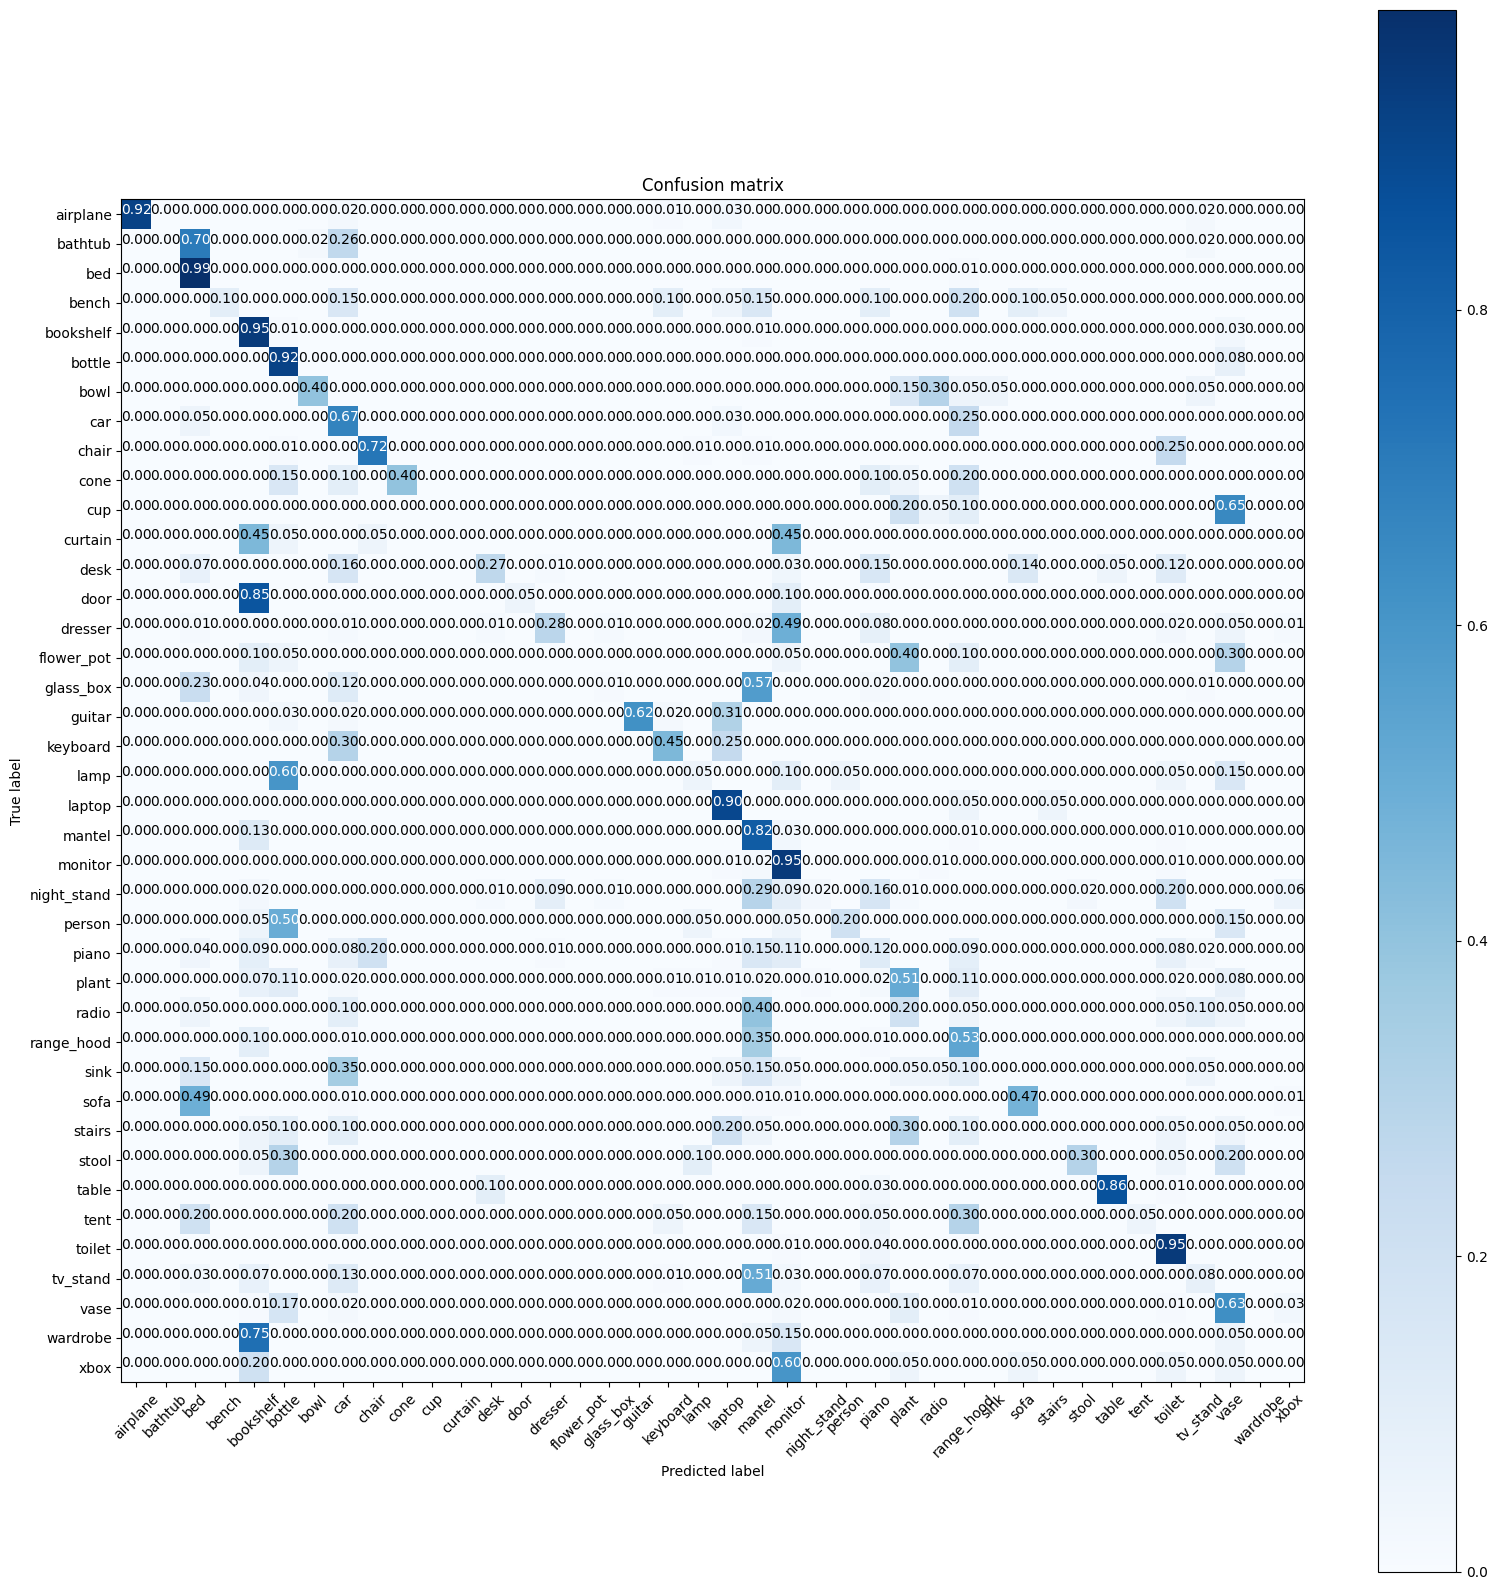

In [15]:
plt.figure(figsize=(16,16))
plot_confusion_matrix(cm, all_class_names, normalize=True)

Confusion matrix, without normalization


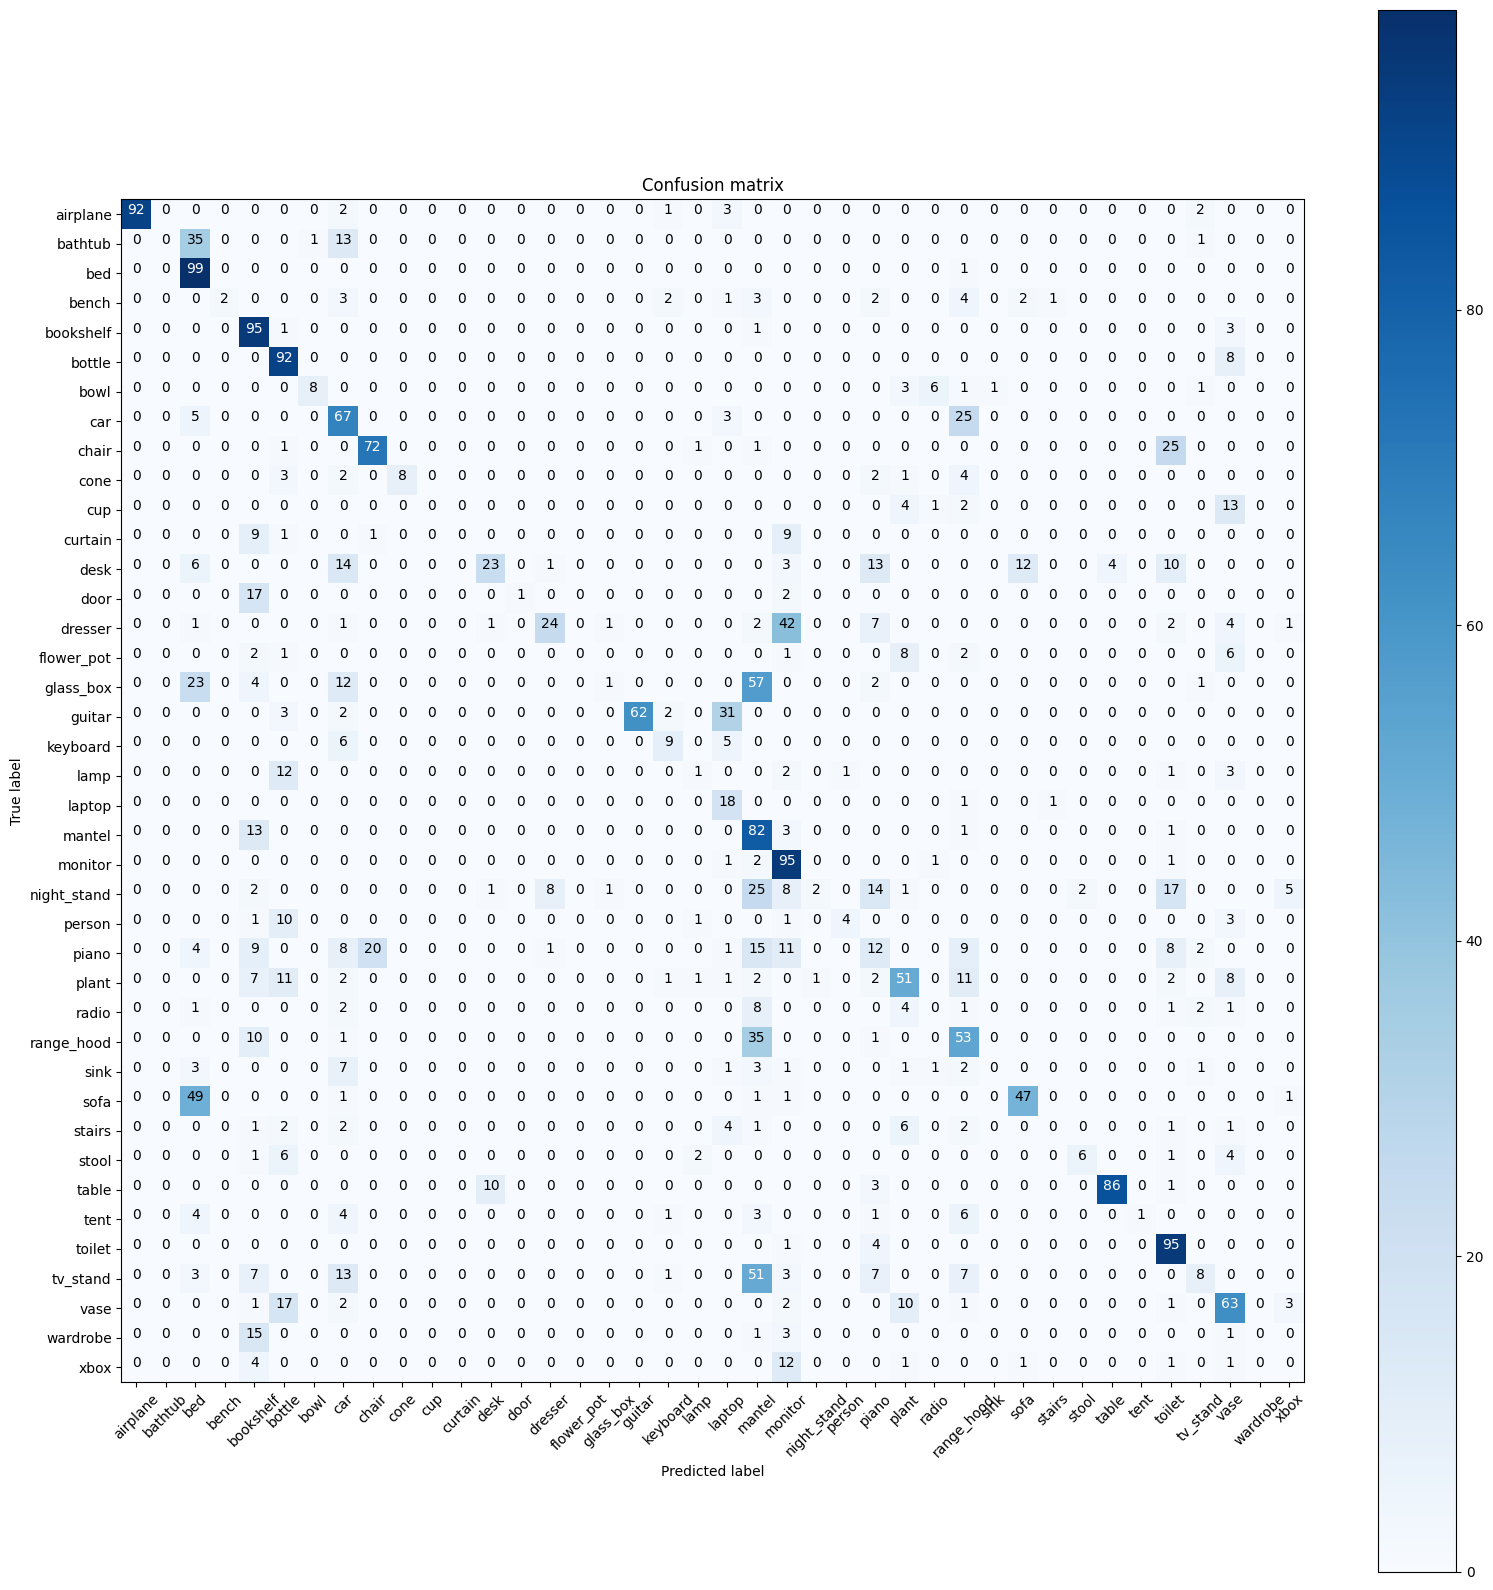

In [16]:
plt.figure(figsize=(16,16))
plot_confusion_matrix(cm, all_class_names, normalize=False)